# 신용카드 사기 거래 탐지 (초중급)

##  학습 목표
1. 클래스 불균형 데이터 다루기
2. Confusion Matrix, Precision, Recall, F1-Score 이해
3. 표준화(Standardization) 적용
4. ROC Curve와 AUC 계산

In [1]:
!pip install -q torch scikit-learn matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)
import torch
import torch.nn as nn
import torch.optim as optim

# 시각화 설정
plt.rcParams['font.size'] = 12
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.grid'] = True

데이터 생성 (클래스 불균형)
- 정상 거래(95%)
- 사기 거래(5%)

In [ ]:
# set(), unique(), nunique() 데이터 중복 제거할 때 활용

In [3]:
# 불균형 데이터 생성해 볼까용? (정상 95%, 사기 5%)

X, y = make_classification(
    n_samples = 10000,        # 전체 샘플(데이터) 개수(행의 수)
    n_features=20,            # 전체 특성(열) 개수
    n_informative=15,         # 실제 정답에 기여하는 유의미한 특성
    n_redundant=5,            # 중복된 특성 >> 제거 대상
    n_classes=2,              # 이진 분류(정상 거래냐 사기 거래냐)
    weights=[0.95, 0.05],     # 클래스 비율(불균형 설정) 0번 : 정상, 1번: 사기
    flip_y = 0.01,            # noise (라벨(y) 무작위로 뒤집는 비율)
    random_state=42

)

In [4]:
# 클래스 분포 확인
# X
# y
np.unique(y, return_counts=True)
# np.unique() 고유한 값 추출(중복 제거)
# return_counts=True
# >> 각 고유값이 몇 번 등장했냐

(array([0, 1]), array([9461,  539]))

In [5]:
unique, counts = np.unique(y, return_counts=True)

In [6]:
print(unique)
print(counts)

[0 1]
[9461  539]


In [7]:
print("정상거래(0): ", counts[0])
print("사기거래(1): ", counts[1])

정상거래(0):  9461
사기거래(1):  539


데이터 분할(계층적 샘플링)

In [9]:
# stratify >> 훈련, 테스트 셋에서 클래스 비율 유지

X_train, X_test, y_train, y_test = \
train_test_split(X,y, test_size=0.2, stratify=y, random_state=42)

In [10]:
X_train[:5]

array([[ 1.80271431,  1.1538857 , -1.32836573, -3.18346766,  1.84595464,
         0.29590928, -0.93380418, -2.81118113, -2.40520559,  1.94241057,
         2.91748109,  0.88028151, -0.52614844, -0.59999735,  2.85790305,
        -3.43716695, -5.5485898 ,  1.52750491, -0.02729916, -9.72927582],
       [ 4.01996533, -1.51131739, -5.0849431 , 10.11502742,  1.68435238,
         2.92429225,  2.30136463,  3.29669269, -6.19554882, -0.80401267,
        -3.00854109, -1.48613647,  4.3589289 , -0.96360065,  2.51213613,
         0.54488284, -0.16843765, -2.11083199, -3.58479686,  2.94427849],
       [ 6.47861823,  0.81977499, -1.43352148,  8.33663508, -0.74276426,
         4.09836694, -2.46403106,  2.21147325, -5.69418447, -1.00700455,
        -0.42901941, -2.6750193 ,  2.68496777,  0.56799387,  5.22147395,
         0.85746511, -6.30428366, -2.56036748, -3.4937209 ,  1.89956284],
       [-2.30028166,  0.32534194,  0.75780157, -3.37405867, -0.90117348,
        -4.25264377,  1.05687539, -2.21291714, -

In [11]:
X_train.shape, X_test.shape

((8000, 20), (2000, 20))

In [12]:
y_train.shape, y_test.shape

((8000,), (2000,))

In [13]:
y_train.sum() / len(y_train) * 100

np.float64(5.3875)

In [14]:
print(f'훈련 데이터 사기 비율: {y_train.sum() / len(y_train) * 100: .2f}%')
print(f'테스트 데이터 사기 비율: {y_test.sum() / len(y_test) * 100: .2f}%')

훈련 데이터 사기 비율:  5.39%
테스트 데이터 사기 비율:  5.40%


데이터 표준화

In [15]:
# 표준화 : (x - x_mean) / std

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# why? transform()만 적용하죠?
# >> 테스트 데이터는 새로운 데이터로 간주하니깐 (건들지마 >> hold-out)

In [16]:
print(f'원본데이터 범위: [{X_train.min():.2f}, {X_train.max():.2f} ]')
print(f'표준화된 범위: [{X_train_scaled.min():.2f}, {X_train_scaled.max():.2f} ]')
print(f'표준화된 평균: [{X_train_scaled.mean():.2f} ]')
print(f'표준화된 표준편차: [{X_train_scaled.std():.2f} ]')

# 표준화 정의 (평균=0, 표준편차=1)
# >> 표준편차 : 편차란 평균에서 떨어진 정도, 표준편차란 평균에서 단위 당(unit) 떨어진 정도

원본데이터 범위: [-30.27, 22.76 ]
표준화된 범위: [-4.55, 4.89 ]
표준화된 평균: [-0.00 ]
표준화된 표준편차: [1.00 ]


Pytorch Tensor 변환

In [17]:
X_train_scaled[:3].shape

(3, 20)

In [18]:
y_train[:5].shape

(5,)

In [19]:
torch.FloatTensor(y_train).view(-1,1)

tensor([[0.],
        [0.],
        [0.],
        ...,
        [0.],
        [0.],
        [0.]])

In [20]:
torch.FloatTensor(y_train).view(-1,1).shape

torch.Size([8000, 1])

In [21]:
X_train_tensor = torch.FloatTensor(X_train_scaled) # (샘플수, 특성 수)
y_train_tensor = torch.FloatTensor(y_train).view(-1,1)

X_test_tensor = torch.FloatTensor(X_test_scaled) # (샘플수, 특성 수)
y_test_tensor = torch.FloatTensor(y_test).view(-1,1)

print(X_train_tensor.shape, y_train_tensor.shape)
print(X_test_tensor.shape, y_test_tensor.shape)

torch.Size([8000, 20]) torch.Size([8000, 1])
torch.Size([2000, 20]) torch.Size([2000, 1])


In [22]:
# 3개의 층을 가진 신경망 모델 생성

class FraudDetectionModel(nn.Module):
    def __init__(self, input_dim):
        super(FraudDetectionModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, 16)
        self.fc2 = nn.Linear(16, 8)
        self.fc3 = nn.Linear(8,1)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

# self.x : 학습 가능한 대상(parameters) 저장하는 데 사용
# >> self.fc1 : layer (가중치가 포함되어 있는 레이어) >> 인스턴스 변수로 저장해야 함
# 그 결과 학습 파라미터(학습대상, w, b) self.f1 >> 저장용 >> 임시 계산하는 지역변수 사용


In [23]:
# 사기거래탐지모델()
model = FraudDetectionModel(input_dim = 20)
print(model)

FraudDetectionModel(
  (fc1): Linear(in_features=20, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=1, bias=True)
  (relu): ReLU()
)


손시함수 및 최적화 알고리즘 설정

In [24]:
counts

array([9461,  539])

In [25]:
[counts[0]/counts[1]]

[np.float64(17.552875695732837)]

In [26]:
pos_weight = torch.tensor([counts[0]/counts[1]])
# 클래스 불균형 조정

# 이진 분류 기준(BCEWithLogitsLoss)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# 최적화
# optimizer = optim.AdamW(model.parameters(), lr=0.001)
optimizer = optim.Adam(model.parameters(), lr=0.001,weight_decay=1e-3)
# weight_decay = 1e-3

In [27]:
pos_weight.item()

print(f'pose_weight: {pos_weight.item():.2f}')

pose_weight: 17.55


모델 학습

In [28]:
num_epochs = 1000

history = {'train_loss':[], 'test_loss':[], 'test_acc':[]}

for epoch in range(num_epochs):
    model.train()
    optimizer.zero_grad()

    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)

    loss.backward()
    optimizer.step()

    # 평가용 모드 전환
    model.eval()
    with torch.no_grad():
        test_outputs = model(X_test_tensor)
        test_loss = criterion(test_outputs, y_test_tensor)
        test_pred = (test_outputs >= 0.0).float()
        test_acc = (test_pred == y_test_tensor).float().mean()

    history['train_loss'].append(loss.item())
    history['test_loss'].append(test_loss.item())
    history['test_acc'].append(test_acc.item())

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch + 1} / {num_epochs}] '
              f'Train Loss: {loss.item():.4f} |'
              f'Test Loss: {test_loss.item():.4f} |'
              f'Test Acc: {test_acc.item():.4f} |'
        )

Epoch [20 / 1000] Train Loss: 1.2883 |Test Loss: 1.2892 |Test Acc: 0.4845 |
Epoch [40 / 1000] Train Loss: 1.2452 |Test Loss: 1.2511 |Test Acc: 0.5470 |
Epoch [60 / 1000] Train Loss: 1.1693 |Test Loss: 1.1874 |Test Acc: 0.5975 |
Epoch [80 / 1000] Train Loss: 1.0515 |Test Loss: 1.0938 |Test Acc: 0.6650 |
Epoch [100 / 1000] Train Loss: 0.9265 |Test Loss: 0.9954 |Test Acc: 0.7410 |
Epoch [120 / 1000] Train Loss: 0.8200 |Test Loss: 0.9133 |Test Acc: 0.8155 |
Epoch [140 / 1000] Train Loss: 0.7327 |Test Loss: 0.8466 |Test Acc: 0.8590 |
Epoch [160 / 1000] Train Loss: 0.6664 |Test Loss: 0.7970 |Test Acc: 0.8780 |
Epoch [180 / 1000] Train Loss: 0.6152 |Test Loss: 0.7629 |Test Acc: 0.8960 |
Epoch [200 / 1000] Train Loss: 0.5734 |Test Loss: 0.7357 |Test Acc: 0.9040 |
Epoch [220 / 1000] Train Loss: 0.5387 |Test Loss: 0.7153 |Test Acc: 0.9155 |
Epoch [240 / 1000] Train Loss: 0.5085 |Test Loss: 0.6958 |Test Acc: 0.9210 |
Epoch [260 / 1000] Train Loss: 0.4820 |Test Loss: 0.6758 |Test Acc: 0.9300 |
Epo

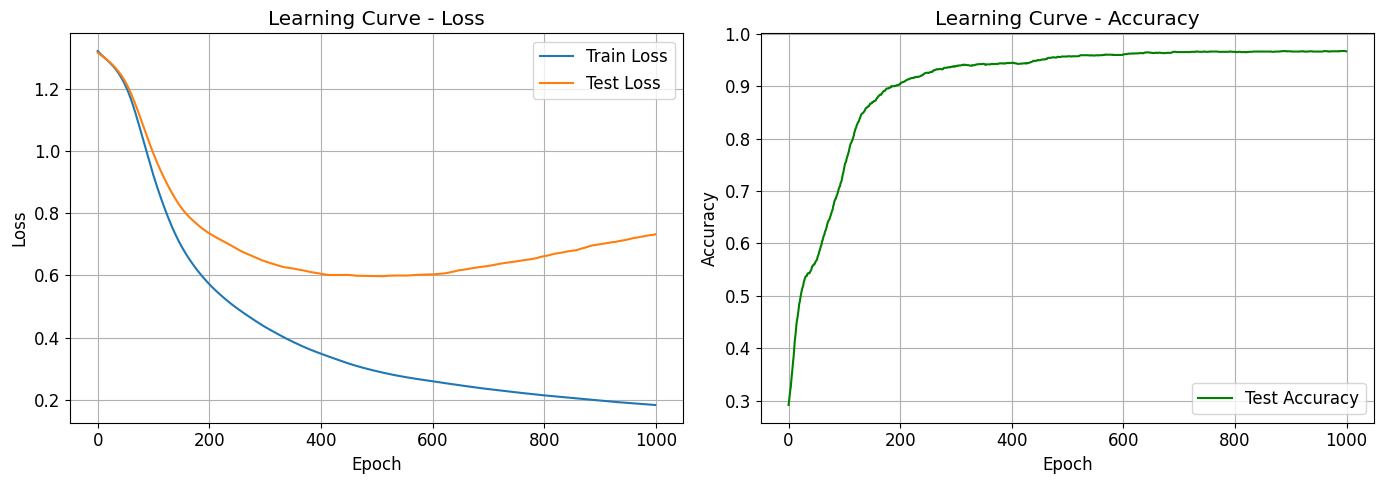

In [29]:
fig, axes = plt.subplots(1,2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['test_loss'], label='Test Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Learning Curve - Loss')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history['test_acc'], label='Test Accuracy', color='green')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Learning Curve - Accuracy')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

상세 평가 지표 계산

In [30]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    print(test_outputs)
    # test_probs = torch.sigmoid(test_outputs) # BCELoss() 때 사용해야 함
    # print(test_probs)
    # test_pred = (test_probs >= 0.5).numpy().astype(int).flatten()
    test_pred = (test_outputs >= 0.0).cpu().numpy().astype(int).flatten()
    # print(test_pred)

tensor([[ 8.4038],
        [-3.5151],
        [-1.7024],
        ...,
        [ 2.7689],
        [-3.6487],
        [-3.7581]])


In [31]:
y_test_np = y_test.astype(int)
print(y_test_np)

[1 0 0 ... 1 0 0]


In [32]:
# 혼동행렬 (confusion matrix)
cm = confusion_matrix(y_test_np, test_pred)
print(cm)

[[1845   47]
 [  19   89]]


In [33]:
print('='*50)
print('Confusion Matrix')
print('='*50)
print("                   Predicted")
print("                   0(정상)   1(사기)")
print(f"Actual  0(정상)     {cm[0,0]}   {cm[0,1]}")
print(f"        0(사기)     {cm[1,0]}   {cm[1,1]}")
print()
print('='*50)

Confusion Matrix
                   Predicted
                   0(정상)   1(사기)
Actual  0(정상)     1845   47
        0(사기)     19   89



In [34]:
cm

array([[1845,   47],
       [  19,   89]])

In [35]:
cm.ravel()  # 2차원 >> 1차원

array([1845,   47,   19,   89])

In [36]:
from sklearn.metrics import *

accuracy = accuracy_score(y_test_np, test_pred)
print(f'정확도: {accuracy:.2f}')

precision = precision_score(y_test_np, test_pred)
print(f'정밀도: {precision:.2f}')

recall = recall_score(y_test_np, test_pred)
print(f'정밀도: {recall:.2f}')

f1 = f1_score(y_test_np, test_pred)
print(f'f1-score: {f1:.2f}')

정확도: 0.97
정밀도: 0.65
정밀도: 0.82
f1-score: 0.73


ROC / AUC

In [37]:
test_probs = torch.sigmoid(test_outputs)
test_probs

tensor([[0.9998],
        [0.0289],
        [0.1541],
        ...,
        [0.9410],
        [0.0254],
        [0.0228]])

In [38]:
test_probs.numpy()

array([[0.99977607],
       [0.0288857 ],
       [0.15414983],
       ...,
       [0.94097346],
       [0.0253637 ],
       [0.02279675]], dtype=float32)

In [48]:
fpr, tpr, thresholds = roc_curve(y_test_np, test_probs.numpy())
# print(fpr)
# print(tpr)

In [43]:
auc = roc_auc_score(y_test_np, test_probs.numpy())
# print(auc)
print(f'auc: {auc * 100 :.2f}%')

auc: 92.68%


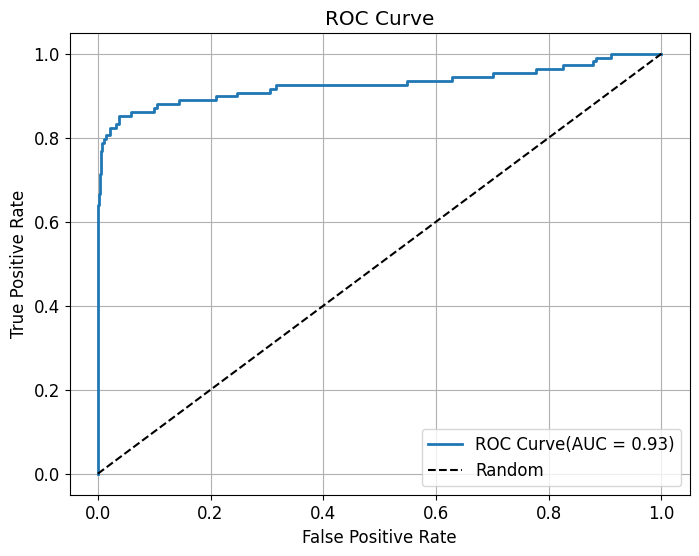

In [49]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC Curve(AUC = {auc:.2f})', linewidth=2)
plt.plot([0,1],[0,1],'k--', label="Random")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

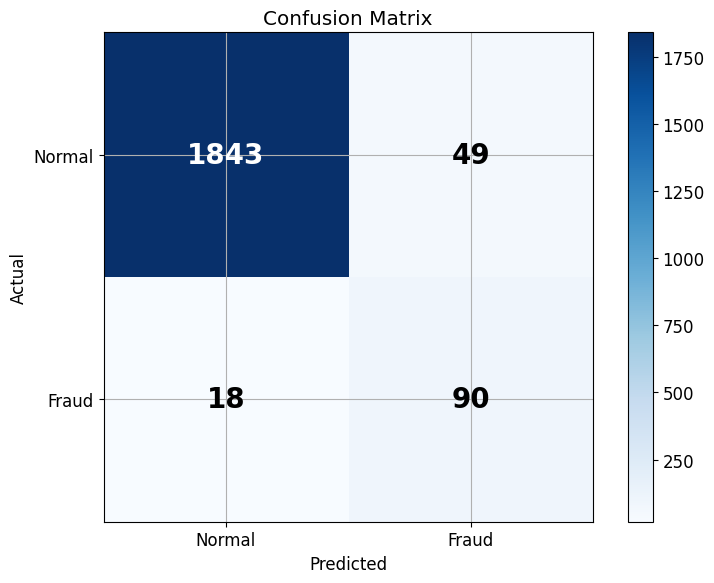

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0,1])
ax.set_yticks([0,1])
ax.set_xticklabels(['Normal', 'Fraud'])
ax.set_yticklabels(['Normal', 'Fraud'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title("Confusion Matrix")

for i in range(2):
  for j in range(2):
    ax.text(j, i, cm[i,j],
            ha = 'center',
            va ='center',
            color='white' if cm[i,j] >  cm.max()/2 else "black",
            fontsize = 20, fontweight='bold'
            )

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
# eos